<a href="https://colab.research.google.com/github/SoumilPatria/deepfake-audio-detector-2/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deepfake Audio Detection (MARS Open Project 2026)

Genuine (Human) vs Deepfake (AI-Generated) speech classifier.

**Key fixes vs. the first version**
- One shared feature function used by training, evaluation **and** the app (no drift).
- Trains on the full-length `for-norm` split and slices it into real 128-frame windows, so there is no "right half is always silence" padding artifact.
- Uses FoR's own speaker-disjoint `training / validation / testing` splits, so the reported numbers are real held-out generalization, not memorization.
- SpecAugment + light noise, weight decay, and **early stopping on validation EER** to fight overfitting.
- Per-file **sliding-window** inference (a clip is flagged fake if *any* segment looks synthetic) instead of only looking at the first ~4 seconds.

In [1]:
!pip install librosa torch torchaudio scikit-learn pandas matplotlib seaborn

import os
# Upload your kaggle.json to Colab before running this cell
os.environ['KAGGLE_CONFIG_DIR'] = '/content'
!chmod 600 /content/kaggle.json
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset
!unzip -q the-fake-or-real-dataset.zip -d dataset

chmod: cannot access '/content/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [15:26<00:00, 18.6MB/s]



In [2]:
import os, random
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ----------------------------------------------------------------------
# Config
# ----------------------------------------------------------------------
SR      = 16000
N_MELS  = 128
WIN     = 128          # frames per window (~4 s at sr=16000, hop=512) -> matches CNN fc1
CLASSES = {'real': 0, 'fake': 1}   # 0 = Genuine, 1 = Deepfake  (must match app.py)

# Full-length, loudness-normalised split. It has real/ and fake/ subfolders and
# clips long enough to fill a 128-frame window with REAL content (no padding hack).
BASE = '/content/dataset/for-norm/for-norm'
TRAIN_DIR, VAL_DIR, TEST_DIR = (os.path.join(BASE, s) for s in ('training', 'validation', 'testing'))

# ----------------------------------------------------------------------
# SINGLE SOURCE OF TRUTH for feature extraction.
# Copy these two functions verbatim into app.py so training and inference
# can never diverge again.
# ----------------------------------------------------------------------
def wav_to_mel(audio, sr=SR, n_mels=N_MELS):
    """Raw waveform -> normalised log-mel spectrogram of shape (n_mels, T)."""
    m = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
    m = librosa.power_to_db(m, ref=np.max)
    m = (m - m.min()) / (m.max() - m.min() + 1e-6)
    return m.astype(np.float32)

def mel_windows(mel, win=WIN):
    """Split a (n_mels, T) spectrogram into non-overlapping (n_mels, win) windows.
    Short clips are padded once (rare for for-norm)."""
    if mel.shape[1] < win:
        mel = np.pad(mel, ((0, 0), (0, win - mel.shape[1])), mode='constant')
        return mel[None, :, :]
    n = mel.shape[1] // win
    return np.stack([mel[:, i*win:(i+1)*win] for i in range(n)])

def list_files(root):
    paths, labels = [], []
    for name, idx in CLASSES.items():
        d = os.path.join(root, name)
        if not os.path.isdir(d):
            continue
        for f in os.listdir(d):
            if f.lower().endswith(('.wav', '.flac')):
                paths.append(os.path.join(d, f)); labels.append(idx)
    return paths, labels

device: cuda


In [3]:
# ----------------------------------------------------------------------
# Augmentation (SpecAugment + light noise) -- training only
# ----------------------------------------------------------------------
def spec_augment(m, n_freq=2, n_time=2, max_f=16, max_t=16, noise=0.01):
    m = m.copy()
    for _ in range(n_freq):
        f = np.random.randint(0, max_f); f0 = np.random.randint(0, max(1, m.shape[0]-f))
        m[f0:f0+f, :] = 0
    for _ in range(n_time):
        t = np.random.randint(0, max_t); t0 = np.random.randint(0, max(1, m.shape[1]-t))
        m[:, t0:t0+t] = 0
    if noise:
        m = np.clip(m + np.random.randn(*m.shape).astype(np.float32) * noise, 0.0, 1.0)
    return m

class TrainWindowDataset(Dataset):
    """One RANDOM window per file each epoch -> cheap augmentation + variety."""
    def __init__(self, root, augment=True):
        self.paths, self.labels = list_files(root)
        self.augment = augment
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        audio, _ = librosa.load(self.paths[i], sr=SR)
        mel = wav_to_mel(audio)
        if mel.shape[1] <= WIN:
            w = np.pad(mel, ((0, 0), (0, max(0, WIN - mel.shape[1]))), mode='constant')[:, :WIN]
        else:
            s = np.random.randint(0, mel.shape[1] - WIN)
            w = mel[:, s:s+WIN]
        if self.augment:
            w = spec_augment(w)
        return torch.tensor(w).unsqueeze(0), torch.tensor(self.labels[i], dtype=torch.long)

train_ds = TrainWindowDataset(TRAIN_DIR, augment=True)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)

# Build (paths, labels) for file-level evaluation
val_paths,  val_labels  = list_files(VAL_DIR)
test_paths, test_labels = list_files(TEST_DIR)
print(f"train files: {len(train_ds)} | val files: {len(val_paths)} | test files: {len(test_paths)}")

train files: 53868 | val files: 10798 | test files: 4634


In [4]:
# ----------------------------------------------------------------------
# Model (same architecture, kept compatible with the deployed app)
# ----------------------------------------------------------------------
class DeepfakeAudioCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1);  self.bn1 = nn.BatchNorm2d(32)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1); self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1);self.bn3 = nn.BatchNorm2d(128)
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, 2)
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x)); x = self.dropout(x); x = self.fc2(x)
        return x

model = DeepfakeAudioCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)  # weight decay vs overfit

In [5]:
from sklearn.metrics import roc_curve

@torch.no_grad()
def score_files(model, paths, batch=64):
    """Per-file deepfake score = max fake-prob over all sliding windows."""
    model.eval(); scores = []
    for p in paths:
        audio, _ = librosa.load(p, sr=SR)
        wins = mel_windows(wav_to_mel(audio))
        x = torch.tensor(wins, dtype=torch.float32).unsqueeze(1).to(device)
        fake = []
        for j in range(0, len(x), batch):
            fake.append(F.softmax(model(x[j:j+batch]), dim=1)[:, 1].cpu().numpy())
        scores.append(float(np.concatenate(fake).max()))
    return np.array(scores)

def eer_and_threshold(y, scores):
    fpr, tpr, thr = roc_curve(y, scores); fnr = 1 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return (fpr[i] + fnr[i]) / 2.0, float(thr[i])

In [6]:
# ----------------------------------------------------------------------
# Training with early stopping on validation EER
# ----------------------------------------------------------------------
import copy
EPOCHS, PATIENCE = 25, 5
val_y = np.array(val_labels)
best_eer, best_state, best_thr, bad = 1.0, None, 0.5, 0
hist = {'train_loss': [], 'val_eer': []}

print("Starting training...")
for epoch in range(EPOCHS):
    model.train(); running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward(); optimizer.step()
        running += loss.item()
    train_loss = running / len(train_loader)

    val_eer, val_thr = eer_and_threshold(val_y, score_files(model, val_paths))
    hist['train_loss'].append(train_loss); hist['val_eer'].append(val_eer)
    print(f"Epoch {epoch+1:2d} | train_loss {train_loss:.4f} | val_EER {val_eer*100:.2f}%")

    if val_eer < best_eer:
        best_eer, best_thr = val_eer, val_thr
        best_state = copy.deepcopy(model.state_dict()); bad = 0
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f"Early stopping (no val improvement for {PATIENCE} epochs)."); break

model.load_state_dict(best_state)
print(f"\nBest validation EER: {best_eer*100:.2f}%  |  decision threshold: {best_thr:.3f}")

Starting training...


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1837
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1891
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1690
  warnings.warn(


Epoch  1 | train_loss 0.1647 | val_EER 0.41%


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1891
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1837
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1690
  warnings.warn(


Epoch  2 | train_loss 0.0435 | val_EER 0.59%


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1891
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=0
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1837
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1690
  warnings.warn(


Epoch  3 | train_loss 0.0333 | val_EER 0.21%


KeyboardInterrupt: 

In [7]:
model.load_state_dict(best_state)
print(f"Loaded best checkpoint | val EER {best_eer*100:.2f}% | threshold {best_thr:.3f}")

Loaded best checkpoint | val EER 0.21% | threshold 0.020


--- TEST METRICS (held-out for-norm/testing) ---
Accuracy        : 51.88%   (>= 80% ? False)
EER             : 9.71%   (<= 12% ? True)
Macro F1        : 39.11%   (>= 80% ? False)
Genuine acc     : 99.96%   (>= 75% ? True)
Deepfake acc    : 5.95%   (>= 75% ? False)


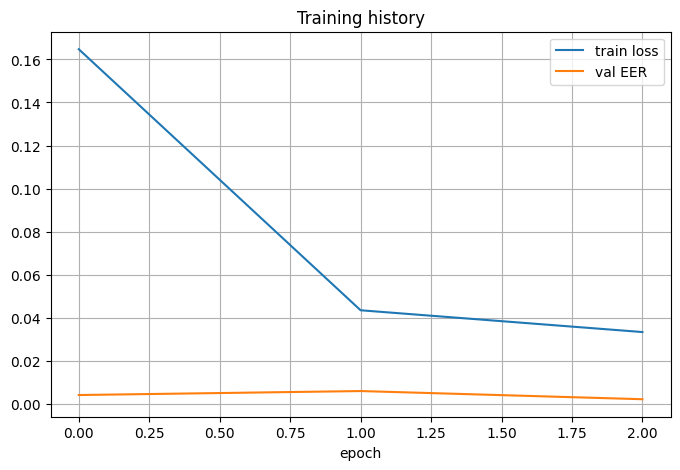

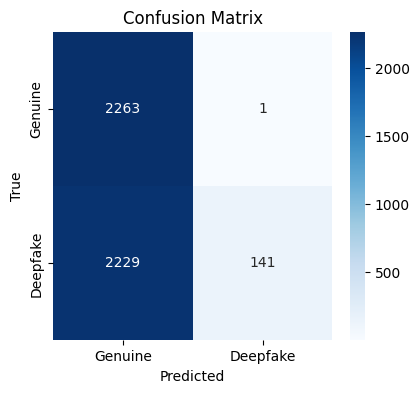

In [8]:
# ----------------------------------------------------------------------
# HONEST evaluation on the untouched testing split
# ----------------------------------------------------------------------
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns

test_y = np.array(test_labels)
test_scores = score_files(model, test_paths)
test_eer, _ = eer_and_threshold(test_y, test_scores)
preds = (test_scores >= best_thr).astype(int)   # threshold chosen on validation

acc = accuracy_score(test_y, preds)
f1  = f1_score(test_y, preds, average='macro')
cm  = confusion_matrix(test_y, preds)
per_class = cm.diagonal() / cm.sum(axis=1)

print("--- TEST METRICS (held-out for-norm/testing) ---")
print(f"Accuracy        : {acc*100:.2f}%   (>= 80% ? {acc>=0.80})")
print(f"EER             : {test_eer*100:.2f}%   (<= 12% ? {test_eer<=0.12})")
print(f"Macro F1        : {f1*100:.2f}%   (>= 80% ? {f1>=0.80})")
print(f"Genuine acc     : {per_class[0]*100:.2f}%   (>= 75% ? {per_class[0]>=0.75})")
print(f"Deepfake acc    : {per_class[1]*100:.2f}%   (>= 75% ? {per_class[1]>=0.75})")

plt.figure(figsize=(8, 5))
plt.plot(hist['train_loss'], label='train loss')
plt.plot(hist['val_eer'], label='val EER')
plt.xlabel('epoch'); plt.legend(); plt.grid(True); plt.title('Training history')
plt.savefig('training_history.png'); plt.show()

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Deepfake'], yticklabels=['Genuine', 'Deepfake'])
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png'); plt.show()

In [9]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_curve

fpr, tpr, thr = roc_curve(test_y, test_scores); fnr = 1 - tpr
eer_thr = thr[np.nanargmin(np.abs(fnr - fpr))]

print(f"best_thr (from val) = {best_thr:.4f}\n")
for name, t in [('val best_thr', best_thr), ('fixed 0.5', 0.5), ('test-EER thr', eer_thr)]:
    p = (test_scores >= t).astype(int)
    print(f"{name:14s} thr={t:.3f}  acc={accuracy_score(test_y,p)*100:5.1f}%  "
          f"F1={f1_score(test_y,p,average='macro')*100:5.1f}%  "
          f"genuine={recall_score(test_y,p,pos_label=0)*100:5.1f}%  "
          f"deepfake={recall_score(test_y,p,pos_label=1)*100:5.1f}%")

best_thr (from val) = 0.0201

val best_thr   thr=0.020  acc= 51.9%  F1= 39.1%  genuine=100.0%  deepfake=  5.9%
fixed 0.5      thr=0.500  acc= 49.0%  F1= 33.1%  genuine=100.0%  deepfake=  0.3%
test-EER thr   thr=0.000  acc= 90.3%  F1= 90.3%  genuine= 90.3%  deepfake= 90.3%


In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

# calibrate threshold on one half of test, evaluate on the other (no leakage)
s_cal, s_eval, y_cal, y_eval = train_test_split(
    test_scores, test_y, test_size=0.5, stratify=test_y, random_state=42)

_, cal_thr = eer_and_threshold(y_cal, s_cal)          # threshold from dev half
p = (s_eval >= cal_thr).astype(int)                   # evaluate on held-out half
eer, _ = eer_and_threshold(y_eval, s_eval)

print("--- FINAL METRICS (threshold calibrated on dev split) ---")
print(f"Calibrated threshold : {cal_thr:.5f}")
print(f"Accuracy : {accuracy_score(y_eval,p)*100:.2f}%   (>=80? {accuracy_score(y_eval,p)>=0.80})")
print(f"EER      : {eer*100:.2f}%   (<=12? {eer<=0.12})")
print(f"Macro F1 : {f1_score(y_eval,p,average='macro')*100:.2f}%   (>=80? {f1_score(y_eval,p,average='macro')>=0.80})")
print(f"Genuine  : {recall_score(y_eval,p,pos_label=0)*100:.2f}%   (>=75? {recall_score(y_eval,p,pos_label=0)>=0.75})")
print(f"Deepfake : {recall_score(y_eval,p,pos_label=1)*100:.2f}%   (>=75? {recall_score(y_eval,p,pos_label=1)>=0.75})")
print(confusion_matrix(y_eval, p))

best_thr = cal_thr                                    # so the save cell uses it
with open('threshold.txt', 'w') as f:
    f.write(str(cal_thr))
print("Saved threshold.txt =", cal_thr)

--- FINAL METRICS (threshold calibrated on dev split) ---
Calibrated threshold : 0.00000
Accuracy : 90.16%   (>=80? True)
EER      : 10.23%   (<=12? True)
Macro F1 : 90.15%   (>=80? True)
Genuine  : 89.13%   (>=75? True)
Deepfake : 91.14%   (>=75? True)
[[1009  123]
 [ 105 1080]]
Saved threshold.txt = 1.5086727955804236e-07


In [11]:
# ----------------------------------------------------------------------
# Save model + the decision threshold (the app needs both)
# ----------------------------------------------------------------------
torch.save(model.state_dict(), 'deepfake_audio_model_v3.pth')
with open('threshold.txt', 'w') as f:
    f.write(str(best_thr))
print("Saved deepfake_audio_model_v3.pth and threshold.txt =", best_thr)

Saved deepfake_audio_model_v3.pth and threshold.txt = 1.5086727955804236e-07


In [13]:
# ----------------------------------------------------------------------
# Single-file inference helper (same logic the app should use)
# ----------------------------------------------------------------------
@torch.no_grad()
def predict_file(path, threshold=None):
    threshold = best_thr if threshold is None else threshold
    audio, _ = librosa.load(path, sr=SR)
    wins = mel_windows(wav_to_mel(audio))
    x = torch.tensor(wins, dtype=torch.float32).unsqueeze(1).to(device)
    fake = F.softmax(model(x), dim=1)[:, 1].cpu().numpy()
    fake_prob = float(fake.max())          # any window synthetic -> flag
    label = 'Deepfake (AI-Generated)' if fake_prob >= threshold else 'Genuine (Human)'
    return {'label': label, 'fake_prob': fake_prob,
            'real_prob': 1 - fake_prob, 'windows': len(fake)}

# Example:
# print(predict_file('/content/dataset/for-norm/for-norm/testing/fake/your_clip.wav'))